In [89]:
# ======================================================================
# NOTEBOOK 12 — MULTI-SEED ROBUSTNESS & REPRODUCIBILITY ANALYSIS
# ======================================================================
 # ----------------------------------------------------------------------
# GLOBAL REPRODUCIBILITY CONFIGURATION
# ----------------------------------------------------------------------
import pandas as pd
import numpy as np
import optuna
import random 
import xgboost as xgb
import joblib
import os
from pathlib import Path
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("NOTEBOOK 12 — MULTI-SEED ROBUSTNESS")
print("AND REPRODUCIBILITY ANALYSIS")
print("=" * 70)

# ----------------------------------------------------------------------
# RANDOM-SEED CONFIGURATION
# ----------------------------------------------------------------------

RANDOM_SEEDS = [42, 123, 7]

# Primary/reference seed used in the locked final model
PRIMARY_SEED = 42

# Validation
assert len(RANDOM_SEEDS) == 3
assert len(set(RANDOM_SEEDS)) == 3
assert PRIMARY_SEED in RANDOM_SEEDS


# Set primary seed for notebook-level operations
random.seed(PRIMARY_SEED)
np.random.seed(PRIMARY_SEED)

# ----------------------------------------------------------------------
# DISPLAY CONFIGURATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("REPRODUCIBILITY CONFIGURATION")
print("=" * 70)

print(f"Random seeds:        {RANDOM_SEEDS}")
print(f"Primary random seed: {PRIMARY_SEED}")
print("Number of seeds:     3")

print()
print("✓ Three random seeds configured")
print("✓ Seeds are unique")
print("✓ Primary seed 42 confirmed")
print("✓ NumPy random state initialized")
print("✓ Python random state initialized")
print("✓ Notebook 12 reproducibility configuration established")

NOTEBOOK 12 — MULTI-SEED ROBUSTNESS
AND REPRODUCIBILITY ANALYSIS

REPRODUCIBILITY CONFIGURATION
Random seeds:        [42, 123, 7]
Primary random seed: 42
Number of seeds:     3

✓ Three random seeds configured
✓ Seeds are unique
✓ Primary seed 42 confirmed
✓ NumPy random state initialized
✓ Python random state initialized
✓ Notebook 12 reproducibility configuration established


In [90]:
# ======================================================================
# Cell 2 -- NOTEBOOK 12 — PROJECT PATH & LOCKED ARTIFACT VALIDATION
# ======================================================================

print("=" * 70)
print("PROJECT PATH & LOCKED ARTIFACT VALIDATION")
print("=" * 70)

import pandas as pd
# ----------------------------------------------------------------------
# PROJECT DIRECTORIES
# ----------------------------------------------------------------------

# — Define project paths/directories
BASE_DIR = Path.cwd()
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data"
FIELD_DIR = DATA_DIR / "field"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT /"models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURE_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
REPORT_DIR = RESULTS_DIR / "reports"
# Create output directories
for folder in [FIGURE_DIR, TABLE_DIR, REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------------------
# DIRECTORY VALIDATION
# ----------------------------------------------------------------------

print(f"Project directory: {PROJECT_ROOT}")
print(f"Processed data:    {PROCESSED_DIR}")
print(f"Models:            {MODELS_DIR}")
print(f"Results:           {RESULTS_DIR}")

assert os.path.isdir(PROJECT_ROOT), \
    "Project directory not found"

assert os.path.isdir(PROCESSED_DIR), \
    "Processed-data directory not found"

assert os.path.isdir(MODELS_DIR), \
    "Model directory not found"

assert os.path.isdir(RESULTS_DIR), \
    "Results directory not found"

print()
print("✓ All project directories validated")

# ----------------------------------------------------------------------
# EXPECTED LOCKED DATASETS
# ----------------------------------------------------------------------

TRAIN_BINARY_PATH = os.path.join(
    PROCESSED_DIR,
    "train_binary.csv"
)

TEST_BINARY_PATH = os.path.join(
    PROCESSED_DIR,
    "test_binary.csv"
)

TRAIN_MULTICLASS_PATH = os.path.join(
    PROCESSED_DIR,
    "train_multiclass.csv"
)

TEST_MULTICLASS_PATH = os.path.join(
    PROCESSED_DIR,
    "test_multiclass.csv"
)

# ----------------------------------------------------------------------
# DATASET EXISTENCE VALIDATION
# ----------------------------------------------------------------------

assert os.path.isfile(TRAIN_BINARY_PATH), \
    "Binary training dataset not found"

assert os.path.isfile(TEST_BINARY_PATH), \
    "Binary testing dataset not found"

assert os.path.isfile(TRAIN_MULTICLASS_PATH), \
    "Multiclass training dataset not found"

assert os.path.isfile(TEST_MULTICLASS_PATH), \
    "Multiclass testing dataset not found"


# ----------------------------------------------------------------------
# LOAD LOCKED DATASETS
# ----------------------------------------------------------------------

train_binary = pd.read_csv(TRAIN_BINARY_PATH)
test_binary = pd.read_csv(TEST_BINARY_PATH)

train_multiclass = pd.read_csv(TRAIN_MULTICLASS_PATH)
test_multiclass = pd.read_csv(TEST_MULTICLASS_PATH)

print()
print("=" * 70)
print("LOCKED DATASETS LOADED")
print("=" * 70)

print(f"Binary training:     {train_binary.shape}")
print(f"Binary testing:      {test_binary.shape}")
print(f"Multiclass training: {train_multiclass.shape}")
print(f"Multiclass testing:  {test_multiclass.shape}")

print()
print("✓ Four locked datasets loaded into memory")
print("✓ Existing CSV files treated as immutable inputs")
print("✓ No data modification performed")
print("✓ Notebook 11 remains untouched")



PROJECT PATH & LOCKED ARTIFACT VALIDATION
Project directory: ..
Processed data:    ..\data\processed
Models:            ..\models
Results:           ..\results

✓ All project directories validated

LOCKED DATASETS LOADED
Binary training:     (468, 62)
Binary testing:      (117, 62)
Multiclass training: (468, 62)
Multiclass testing:  (117, 62)

✓ Four locked datasets loaded into memory
✓ Existing CSV files treated as immutable inputs
✓ No data modification performed
✓ Notebook 11 remains untouched


In [91]:
# ======================================================================
# CELL 3- NOTEBOOK 12 — LOCKED DATASET & TARGET VALIDATION
# ======================================================================

print("=" * 70)
print("LOCKED DATASET & TARGET VALIDATION")
print("=" * 70)

# ----------------------------------------------------------------------
# SHAPE VALIDATION
# ----------------------------------------------------------------------

assert train_binary.shape == (468, 62)
assert test_binary.shape == (117, 62)

assert train_multiclass.shape == (468, 62)
assert test_multiclass.shape == (117, 62)

print()
print("✓ Binary training shape = 468 × 62")
print("✓ Binary testing shape = 117 × 62")
print("✓ Multiclass training shape = 468 × 62")
print("✓ Multiclass testing shape = 117 × 62")

# ----------------------------------------------------------------------
# TARGET COLUMN VALIDATION
# ----------------------------------------------------------------------

assert "RISK_BINARY" in train_binary.columns
assert "RISK_BINARY" in test_binary.columns

assert "RISK_LABEL" in train_multiclass.columns
assert "RISK_LABEL" in test_multiclass.columns

print()
print("=" * 70)
print("TARGET COLUMN VALIDATION")
print("=" * 70)

print("✓ RISK_BINARY target confirmed")
print("✓ RISK_LABEL target confirmed")

# ----------------------------------------------------------------------
# BINARY TARGET VALIDATION
# ----------------------------------------------------------------------

binary_train_classes = sorted(
    train_binary["RISK_BINARY"].unique().tolist()
)

binary_test_classes = sorted(
    test_binary["RISK_BINARY"].unique().tolist()
)

assert binary_train_classes == [0, 1]
assert binary_test_classes == [0, 1]

print()
print("=" * 70)
print("BINARY TARGET VALIDATION")
print("=" * 70)

print("Training distribution:")
print(train_binary["RISK_BINARY"].value_counts().sort_index())

print()
print("Testing distribution:")
print(test_binary["RISK_BINARY"].value_counts().sort_index())

print()
print("✓ Binary classes 0 and 1 confirmed")

# ----------------------------------------------------------------------
# MULTICLASS TARGET VALIDATION
# ----------------------------------------------------------------------

EXPECTED_MULTICLASS_LABELS = {
    "Low Risk",
    "Moderate Risk",
    "High Risk"
}

multi_train_classes = set(
    train_multiclass["RISK_LABEL"].unique()
)

multi_test_classes = set(
    test_multiclass["RISK_LABEL"].unique()
)

assert multi_train_classes == EXPECTED_MULTICLASS_LABELS
assert multi_test_classes == EXPECTED_MULTICLASS_LABELS

#****Replaced****#
#assert train_multiclass["RISK_LABEL"].dtype == object
#assert test_multiclass["RISK_LABEL"].dtype == object
from pandas.api.types import is_string_dtype   

#---With this---#
assert is_string_dtype(train_multiclass["RISK_LABEL"]), \
    f"RISK_LABEL train must be string-like, got {train_multiclass['RISK_LABEL'].dtype}"

assert is_string_dtype(test_multiclass["RISK_LABEL"]), \
    f"RISK_LABEL test must be string-like, got {test_multiclass['RISK_LABEL'].dtype}"
#********************
print()
print("=" * 70)
print("MULTICLASS TARGET VALIDATION")
print("=" * 70)

print("Training distribution:")
print(
    train_multiclass["RISK_LABEL"]
    .value_counts()
    .reindex(
        ["Low Risk", "Moderate Risk", "High Risk"]
    )
)

print()
print("Testing distribution:")
print(
    test_multiclass["RISK_LABEL"]
    .value_counts()
    .reindex(
        ["Low Risk", "Moderate Risk", "High Risk"]
    )
)

print()
print("✓ Low Risk confirmed")
print("✓ Moderate Risk confirmed")
print("✓ High Risk confirmed")
print("✓ Multiclass labels preserved exactly as stored")

# ----------------------------------------------------------------------
# OBSERVATION COUNT VALIDATION
# ----------------------------------------------------------------------

assert len(train_binary) == 468
assert len(test_binary) == 117

assert len(train_multiclass) == 468
assert len(test_multiclass) == 117

print()
print("=" * 70)
print("OBSERVATION VALIDATION")
print("=" * 70)

print("✓ 468 training observations confirmed")
print("✓ 117 independent test observations confirmed")
print("✓ Binary and multiclass datasets use the same partition")

# ----------------------------------------------------------------------
# COLUMN VALIDATION
# ----------------------------------------------------------------------

assert train_binary.shape[1] == 62
assert test_binary.shape[1] == 62

assert train_multiclass.shape[1] == 62
assert test_multiclass.shape[1] == 62

print()
print("✓ 62 columns confirmed in each locked dataset")

# ----------------------------------------------------------------------
# FINAL LOCKED-DATA VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("LOCKED DATASET VALIDATION COMPLETED")
print("=" * 70)

print("✓ All four datasets loaded successfully")
print("✓ Dataset dimensions validated")
print("✓ Target columns validated")
print("✓ Binary target classes validated")
print("✓ Multiclass target labels validated")
print("✓ Training/test observation counts validated")
print("✓ Original multiclass labels preserved")
print("✓ Locked datasets remain unchanged")
print("✓ Independent test set remains isolated")

LOCKED DATASET & TARGET VALIDATION

✓ Binary training shape = 468 × 62
✓ Binary testing shape = 117 × 62
✓ Multiclass training shape = 468 × 62
✓ Multiclass testing shape = 117 × 62

TARGET COLUMN VALIDATION
✓ RISK_BINARY target confirmed
✓ RISK_LABEL target confirmed

BINARY TARGET VALIDATION
Training distribution:
RISK_BINARY
0    244
1    224
Name: count, dtype: int64

Testing distribution:
RISK_BINARY
0    61
1    56
Name: count, dtype: int64

✓ Binary classes 0 and 1 confirmed

MULTICLASS TARGET VALIDATION
Training distribution:
RISK_LABEL
Low Risk         244
Moderate Risk     89
High Risk        135
Name: count, dtype: int64

Testing distribution:
RISK_LABEL
Low Risk         61
Moderate Risk    31
High Risk        25
Name: count, dtype: int64

✓ Low Risk confirmed
✓ Moderate Risk confirmed
✓ High Risk confirmed
✓ Multiclass labels preserved exactly as stored

OBSERVATION VALIDATION
✓ 468 training observations confirmed
✓ 117 independent test observations confirmed
✓ Binary and m

In [92]:
# ======================================================================
# CELL 4--NOTEBOOK 12 — CORRECTED RAW PREDICTOR MATRIX VALIDATION
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — RAW PREDICTOR MATRIX VALIDATION")
print("=" * 70)

# ----------------------------------------------------------------------
# OUTCOME COLUMNS
# ----------------------------------------------------------------------

OUTCOME_COLUMNS = [
    "RISK_BINARY",
    "RISK_LABEL"
]

# ----------------------------------------------------------------------
# CREATE RAW PREDICTOR MATRICES
# ----------------------------------------------------------------------

X_train_binary = train_binary.drop(
    columns=OUTCOME_COLUMNS
)

X_test_binary = test_binary.drop(
    columns=OUTCOME_COLUMNS
)

X_train_multiclass = train_multiclass.drop(
    columns=OUTCOME_COLUMNS
)

X_test_multiclass = test_multiclass.drop(
    columns=OUTCOME_COLUMNS
)

# ----------------------------------------------------------------------
# TARGET VECTORS
# ----------------------------------------------------------------------

y_train_binary = train_binary["RISK_BINARY"].copy()
y_test_binary = test_binary["RISK_BINARY"].copy()

y_train_multiclass = train_multiclass["RISK_LABEL"].copy()
y_test_multiclass = test_multiclass["RISK_LABEL"].copy()

# ----------------------------------------------------------------------
# SHAPE VALIDATION
# ----------------------------------------------------------------------

assert X_train_binary.shape == (468, 60)
assert X_test_binary.shape == (117, 60)

assert X_train_multiclass.shape == (468, 60)
assert X_test_multiclass.shape == (117, 60)

print()
print("=" * 70)
print("RAW PREDICTOR MATRICES")
print("=" * 70)

print(f"Binary training:      {X_train_binary.shape}")
print(f"Binary testing:       {X_test_binary.shape}")
print(f"Multiclass training:  {X_train_multiclass.shape}")
print(f"Multiclass testing:   {X_test_multiclass.shape}")

print()
print("✓ 60 raw predictors confirmed")

# ----------------------------------------------------------------------
# OUTCOME LEAKAGE CHECK
# ----------------------------------------------------------------------

for df in [
    X_train_binary,
    X_test_binary,
    X_train_multiclass,
    X_test_multiclass
]:
    assert "RISK_BINARY" not in df.columns
    assert "RISK_LABEL" not in df.columns

print()
print("=" * 70)
print("OUTCOME EXCLUSION VALIDATION")
print("=" * 70)

print("✓ RISK_BINARY excluded")
print("✓ RISK_LABEL excluded")
print("✓ No outcome variable included in raw predictors")

# ----------------------------------------------------------------------
# TRAIN / TEST FEATURE ORDER
# ----------------------------------------------------------------------

assert list(X_train_binary.columns) == list(
    X_test_binary.columns
)

assert list(X_train_multiclass.columns) == list(
    X_test_multiclass.columns
)

print()
print("=" * 70)
print("TRAIN / TEST FEATURE ORDER")
print("=" * 70)

print("✓ Binary train/test feature order matches")
print("✓ Multiclass train/test feature order matches")

# ----------------------------------------------------------------------
# BINARY / MULTICLASS FEATURE SET
# ----------------------------------------------------------------------

binary_features = list(X_train_binary.columns)
multiclass_features = list(X_train_multiclass.columns)

assert binary_features == multiclass_features

print("✓ Binary and multiclass raw predictor sets match")
print("✓ 60 common raw predictors confirmed")

# ----------------------------------------------------------------------
# DATA-TYPE INFORMATION
# ----------------------------------------------------------------------

binary_numeric = X_train_binary.select_dtypes(
    include=[np.number]
).columns.tolist()

binary_categorical = X_train_binary.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print()
print("=" * 70)
print("RAW PREDICTOR DATA TYPES")
print("=" * 70)

print(
    f"Numeric predictors:      {len(binary_numeric)}"
)

print(
    f"Categorical predictors:  {len(binary_categorical)}"
)

print()
print("Categorical predictors:")
print(binary_categorical)

print()
print("✓ Raw categorical variables retained")
print("✓ No encoding performed in Notebook 12 Cell 4")

# ----------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("✓ CELL 4 — RAW PREDICTOR VALIDATION COMPLETED")
print("=" * 70)

print("✓ 468 × 60 binary training matrix")
print("✓ 117 × 60 binary testing matrix")
print("✓ 468 × 60 multiclass training matrix")
print("✓ 117 × 60 multiclass testing matrix")
print("✓ Both outcome variables excluded")
print("✓ No target leakage introduced")
print("✓ Binary/multiclass predictor sets aligned")
print("✓ Raw categorical variables preserved")
print("✓ No data modified")
print("✓ No model retrained")
print("✓ Notebook 11 remains locked")

NOTEBOOK 12 — RAW PREDICTOR MATRIX VALIDATION

RAW PREDICTOR MATRICES
Binary training:      (468, 60)
Binary testing:       (117, 60)
Multiclass training:  (468, 60)
Multiclass testing:   (117, 60)

✓ 60 raw predictors confirmed

OUTCOME EXCLUSION VALIDATION
✓ RISK_BINARY excluded
✓ RISK_LABEL excluded
✓ No outcome variable included in raw predictors

TRAIN / TEST FEATURE ORDER
✓ Binary train/test feature order matches
✓ Multiclass train/test feature order matches
✓ Binary and multiclass raw predictor sets match
✓ 60 common raw predictors confirmed

RAW PREDICTOR DATA TYPES
Numeric predictors:      49
Categorical predictors:  11

Categorical predictors:
['SID', 'ASSIGN_LATE', 'Age_group', 'Gender', 'Programme', 'SES', 'Financial_diff', 'Employment_hrs', 'Study_hrs_day', 'Sleep_hrs', 'Self_risk_percep']

✓ Raw categorical variables retained
✓ No encoding performed in Notebook 12 Cell 4

✓ CELL 4 — RAW PREDICTOR VALIDATION COMPLETED
✓ 468 × 60 binary training matrix
✓ 117 × 60 binary tes

In [93]:
# ======================================================================
# CELL 5 --NOTEBOOK 12 — MODEL-READY DATASET VALIDATION
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — MODEL-READY DATASET VALIDATION")
print("=" * 70)

# ----------------------------------------------------------------------
# MODEL-READY PATHS
# ----------------------------------------------------------------------

TRAIN_BINARY_MODEL_PATH = os.path.join(
    PROCESSED_DIR,
    "train_binary_model.csv"
)

TEST_BINARY_MODEL_PATH = os.path.join(
    PROCESSED_DIR,
    "test_binary_model.csv"
)

TRAIN_MULTICLASS_MODEL_PATH = os.path.join(
    PROCESSED_DIR,
    "train_multiclass_model.csv"
)

TEST_MULTICLASS_MODEL_PATH = os.path.join(
    PROCESSED_DIR,
    "test_multiclass_model.csv"
)

# ----------------------------------------------------------------------
# FILE EXISTENCE VALIDATION
# ----------------------------------------------------------------------

assert os.path.isfile(TRAIN_BINARY_MODEL_PATH)
assert os.path.isfile(TEST_BINARY_MODEL_PATH)
assert os.path.isfile(TRAIN_MULTICLASS_MODEL_PATH)
assert os.path.isfile(TEST_MULTICLASS_MODEL_PATH)

print()
print("✓ Binary model-ready training file found")
print("✓ Binary model-ready testing file found")
print("✓ Multiclass model-ready training file found")
print("✓ Multiclass model-ready testing file found")

# ----------------------------------------------------------------------
# LOAD MODEL-READY DATA
# ----------------------------------------------------------------------

train_binary_model = pd.read_csv(
    TRAIN_BINARY_MODEL_PATH
)

test_binary_model = pd.read_csv(
    TEST_BINARY_MODEL_PATH
)

train_multiclass_model = pd.read_csv(
    TRAIN_MULTICLASS_MODEL_PATH
)

test_multiclass_model = pd.read_csv(
    TEST_MULTICLASS_MODEL_PATH
)

# ----------------------------------------------------------------------
# SHAPE VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("MODEL-READY DATASET SHAPES")
print("=" * 70)

print(
    f"Binary training model:      "
    f"{train_binary_model.shape}"
)

print(
    f"Binary testing model:       "
    f"{test_binary_model.shape}"
)

print(
    f"Multiclass training model:  "
    f"{train_multiclass_model.shape}"
)

print(
    f"Multiclass testing model:   "
    f"{test_multiclass_model.shape}"
)

# ----------------------------------------------------------------------
# OBSERVATION VALIDATION
# ----------------------------------------------------------------------

assert len(train_binary_model) == 468
assert len(test_binary_model) == 117

assert len(train_multiclass_model) == 468
assert len(test_multiclass_model) == 117

print()
print("✓ 468 training observations confirmed")
print("✓ 117 independent test observations confirmed")

# ----------------------------------------------------------------------
# TARGET VALIDATION
# ----------------------------------------------------------------------

assert "RISK_BINARY" in train_binary_model.columns
assert "RISK_BINARY" in test_binary_model.columns

assert "RISK_LABEL" in train_multiclass_model.columns
assert "RISK_LABEL" in test_multiclass_model.columns

print()
print("=" * 70)
print("MODEL-READY TARGET VALIDATION")
print("=" * 70)

print("✓ RISK_BINARY present in binary model-ready data")
print("✓ RISK_LABEL present in multiclass model-ready data")

# ----------------------------------------------------------------------
# PROGRAMME_ENT VALIDATION
# ----------------------------------------------------------------------

assert "Programme_ENT" in train_binary_model.columns
assert "Programme_ENT" in test_binary_model.columns

assert "Programme_ENT" in train_multiclass_model.columns
assert "Programme_ENT" in test_multiclass_model.columns

print()
print("=" * 70)
print("ENCODED FEATURE VALIDATION")
print("=" * 70)

print("✓ Programme_ENT present in binary model-ready data")
print("✓ Programme_ENT present in multiclass model-ready data")

# ----------------------------------------------------------------------
# DISPLAY COLUMN COUNTS
# ----------------------------------------------------------------------

binary_predictors_model = [
    c for c in train_binary_model.columns
    if c != "RISK_BINARY"
]

multiclass_predictors_model = [
    c for c in train_multiclass_model.columns
    if c != "RISK_LABEL"
]

print()
print("=" * 70)
print("MODEL-READY PREDICTOR COUNTS")
print("=" * 70)

print(
    f"Binary model-ready predictors:      "
    f"{len(binary_predictors_model)}"
)

print(
    f"Multiclass model-ready predictors:  "
    f"{len(multiclass_predictors_model)}"
)

# ----------------------------------------------------------------------
# CRITICAL CROSS-TARGET INSPECTION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("CROSS-TARGET INSPECTION")
print("=" * 70)

print(
    "RISK_LABEL in binary model-ready data:",
    "RISK_LABEL" in train_binary_model.columns
)

print(
    "RISK_BINARY in multiclass model-ready data:",
    "RISK_BINARY" in train_multiclass_model.columns
)

# ----------------------------------------------------------------------
# PROGRAMME / PROGRAMME_ENT INSPECTION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("PROGRAMME ENCODING INSPECTION")
print("=" * 70)

print(
    "Programme in model-ready data:",
    "Programme" in train_binary_model.columns
)

print(
    "Programme_ENT in model-ready data:",
    "Programme_ENT" in train_binary_model.columns
)

if "Programme_ENT" in train_binary_model.columns:
    print()
    print("Programme_ENT value counts:")
    print(
        train_binary_model["Programme_ENT"]
        .value_counts(dropna=False)
    )

# ----------------------------------------------------------------------
# FINAL STATUS
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("✓ CELL 5 MODEL-READY DATASET INSPECTION COMPLETED")
print("=" * 70)

print("✓ Existing model-ready artifacts loaded")
print("✓ No preprocessing performed")
print("✓ No encoding performed")
print("✓ No data modified")
print("✓ No model retrained")
print("✓ Notebook 11 remains locked")

NOTEBOOK 12 — MODEL-READY DATASET VALIDATION

✓ Binary model-ready training file found
✓ Binary model-ready testing file found
✓ Multiclass model-ready training file found
✓ Multiclass model-ready testing file found

MODEL-READY DATASET SHAPES
Binary training model:      (468, 62)
Binary testing model:       (117, 62)
Multiclass training model:  (468, 62)
Multiclass testing model:   (117, 62)

✓ 468 training observations confirmed
✓ 117 independent test observations confirmed

MODEL-READY TARGET VALIDATION
✓ RISK_BINARY present in binary model-ready data
✓ RISK_LABEL present in multiclass model-ready data

ENCODED FEATURE VALIDATION
✓ Programme_ENT present in binary model-ready data
✓ Programme_ENT present in multiclass model-ready data

MODEL-READY PREDICTOR COUNTS
Binary model-ready predictors:      61
Multiclass model-ready predictors:  61

CROSS-TARGET INSPECTION
RISK_LABEL in binary model-ready data: False
RISK_BINARY in multiclass model-ready data: False

PROGRAMME ENCODING INSPE

In [94]:
# ======================================================================
# CELL 6--NOTEBOOK 12 — FINAL 49-FEATURE SP-XGBOOST PROVENANCE VALIDATION
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — FINAL 49-FEATURE SP-XGBOOST PROVENANCE")
print("=" * 70)

# ----------------------------------------------------------------------
# LOAD NOTEBOOK 11 SHAP FEATURE ARTIFACT
# ----------------------------------------------------------------------

SHAP_FEATURE_FILE = os.path.join(
    RESULTS_DIR,
    "statistical_analysis",
    "final_sp_xgboost_shap_feature_statistics.csv"
)

assert os.path.isfile(
    SHAP_FEATURE_FILE
), "Notebook 11 SHAP feature-statistics file not found"

shap_feature_stats = pd.read_csv(
    SHAP_FEATURE_FILE
)

print()
print("✓ Notebook 11 SHAP feature-statistics file found")

# ----------------------------------------------------------------------
# IDENTIFY FEATURE COLUMN
# ----------------------------------------------------------------------

assert "Feature" in shap_feature_stats.columns

shap_features = (
    shap_feature_stats["Feature"]
    .dropna()
    .astype(str)
    .tolist()
)

print()
print("=" * 70)
print("NOTEBOOK 11 SHAP FEATURE ARTIFACT")
print("=" * 70)

print(
    f"Features stored: {len(shap_features)}"
)

# ----------------------------------------------------------------------
# UNIQUE FEATURE VALIDATION
# ----------------------------------------------------------------------

assert len(shap_features) == 49
assert len(set(shap_features)) == 49

print("✓ Exactly 49 SHAP-selected features found")
print("✓ All 49 feature names are unique")

# ----------------------------------------------------------------------
# MODEL-READY FEATURE SPACE
# ----------------------------------------------------------------------

model_ready_features = [
    c for c in train_binary_model.columns
    if c != "RISK_BINARY"
]

assert len(model_ready_features) == 61

print()
print("=" * 70)
print("61-FEATURE MODEL-READY SPACE")
print("=" * 70)

print("✓ 61 model-ready predictors confirmed")

# ----------------------------------------------------------------------
# PROVENANCE CHECK
# ----------------------------------------------------------------------

unmatched_features = [
    feature
    for feature in shap_features
    if feature not in model_ready_features
]

print()
print("=" * 70)
print("49-FEATURE PROVENANCE CHECK")
print("=" * 70)

print(
    "SHAP features not found in 61-feature model space:"
)

print(unmatched_features)

# ----------------------------------------------------------------------
# CRITICAL ASSERTION
# ----------------------------------------------------------------------

assert len(unmatched_features) == 0, (
    "One or more Notebook 11 SHAP features are not present "
    "in the established 61-feature model-ready dataset."
)

print()
print("✓ All 49 Notebook 11 features exist in the 61-feature model space")
print("✓ 49-feature SP-XGBoost provenance confirmed")

# ----------------------------------------------------------------------
# CREATE FINAL FEATURE LIST
# ----------------------------------------------------------------------

FINAL_SP_XGBOOST_FEATURES = shap_features.copy()

# ----------------------------------------------------------------------
# FINAL MATRIX CONSTRUCTION
# ----------------------------------------------------------------------

X_train_sp = train_binary_model[
    FINAL_SP_XGBOOST_FEATURES
].copy()

X_test_sp = test_binary_model[
    FINAL_SP_XGBOOST_FEATURES
].copy()

y_train_sp = train_binary_model[
    "RISK_BINARY"
].copy()

y_test_sp = test_binary_model[
    "RISK_BINARY"
].copy()

# ----------------------------------------------------------------------
# MATRIX VALIDATION
# ----------------------------------------------------------------------

assert X_train_sp.shape == (468, 49)
assert X_test_sp.shape == (117, 49)

assert y_train_sp.shape == (468,)
assert y_test_sp.shape == (117,)

assert list(X_train_sp.columns) == FINAL_SP_XGBOOST_FEATURES
assert list(X_test_sp.columns) == FINAL_SP_XGBOOST_FEATURES

# ----------------------------------------------------------------------
# PROGRAMME_ENT VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("FINAL SP-XGBOOST FEATURE SPACE")
print("=" * 70)

print(
    f"Training matrix: {X_train_sp.shape}"
)

print(
    f"Testing matrix:  {X_test_sp.shape}"
)

print(
    "Programme_ENT selected:",
    "Programme_ENT" in FINAL_SP_XGBOOST_FEATURES
)

print()
print("Final 49 features:")
for i, feature in enumerate(
    FINAL_SP_XGBOOST_FEATURES,
    start=1
):
    print(f"{i:2d}. {feature}")

# ----------------------------------------------------------------------
# FINAL VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("✓ CELL 6 — 49-FEATURE PROVENANCE VALIDATED")
print("=" * 70)

print("✓ 61 model-ready predictors confirmed")
print("✓ Notebook 11 49-feature artifact loaded")
print("✓ All 49 features found in model-ready space")
print("✓ Final SP-XGBoost training matrix = 468 × 49")
print("✓ Final SP-XGBoost testing matrix = 117 × 49")
print("✓ Feature order preserved")
print("✓ No data modified")
print("✓ No model retrained")
print("✓ Notebook 11 remains locked")

NOTEBOOK 12 — FINAL 49-FEATURE SP-XGBOOST PROVENANCE

✓ Notebook 11 SHAP feature-statistics file found

NOTEBOOK 11 SHAP FEATURE ARTIFACT
Features stored: 49
✓ Exactly 49 SHAP-selected features found
✓ All 49 feature names are unique

61-FEATURE MODEL-READY SPACE
✓ 61 model-ready predictors confirmed

49-FEATURE PROVENANCE CHECK
SHAP features not found in 61-feature model space:
[]

✓ All 49 Notebook 11 features exist in the 61-feature model space
✓ 49-feature SP-XGBoost provenance confirmed

FINAL SP-XGBOOST FEATURE SPACE
Training matrix: (468, 49)
Testing matrix:  (117, 49)
Programme_ENT selected: True

Final 49 features:
 1. GPA_S1
 2. Persists when difficult
 3. Takes rest breaks
 4. Anxious about assessments
 5. Confident in clinical skills
 6. Programme_ENT
 7. Manages time effectively
 8. Schedule conflicts
 9. CA_AVG
10. Adequate advisory support
11. Hopeless/unmotivated
12. ATT_RATE
13. ASSIGN_LATE
14. Self_risk_percep
15. Sets academic goals
16. EXAM_AVG
17. Sleep_hrs
18. Und

In [95]:
# ======================================================================
#CELL 7-- NOTEBOOK 12 — THREE-SEED SP-XGBOOST ROBUSTNESS PROTOCOL
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — THREE-SEED SP-XGBOOST ROBUSTNESS PROTOCOL")
print("=" * 70)

# ----------------------------------------------------------------------
# RANDOM SEEDS
# ----------------------------------------------------------------------

RANDOM_SEEDS = [42, 123, 7]

assert len(RANDOM_SEEDS) == 3
assert len(set(RANDOM_SEEDS)) == 3
assert 42 in RANDOM_SEEDS

print()
print("Random seeds:", RANDOM_SEEDS)

# ----------------------------------------------------------------------
# FINAL FEATURE SPACE
# ----------------------------------------------------------------------

assert len(FINAL_SP_XGBOOST_FEATURES) == 49

assert X_train_sp.shape == (468, 49)
assert X_test_sp.shape == (117, 49)

print()
print("=" * 70)
print("FINAL FEATURE SPACE")
print("=" * 70)

print("Predictors:", len(FINAL_SP_XGBOOST_FEATURES))
print("Training observations:", len(X_train_sp))
print("Testing observations:", len(X_test_sp))

print("✓ 49 predictors locked")
print("✓ 468 training observations locked")
print("✓ 117 independent test observations locked")

# ----------------------------------------------------------------------
# TARGET VALIDATION
# ----------------------------------------------------------------------

assert set(y_train_sp.unique()) == {0, 1}
assert set(y_test_sp.unique()) == {0, 1}

print()
print("=" * 70)
print("BINARY TARGET")
print("=" * 70)

print("Training distribution:")
print(y_train_sp.value_counts().sort_index())

print()
print("Testing distribution:")
print(y_test_sp.value_counts().sort_index())

print("✓ Binary target confirmed")
print("✓ Target remains unchanged across seeds")

# ----------------------------------------------------------------------
# TEST-SET ISOLATION
# ----------------------------------------------------------------------

TEST_SET_LOCKED = True

assert TEST_SET_LOCKED is True

print()
print("=" * 70)
print("TEST-SET ISOLATION")
print("=" * 70)

print("✓ Independent test set designated for final evaluation only")
print("✓ No seed-specific fitting will use X_test_sp")
print("✓ No seed-specific fitting will use y_test_sp")

# ----------------------------------------------------------------------
# MODEL CONFIGURATION PLACEHOLDER
# ----------------------------------------------------------------------
# IMPORTANT:
# The exact best parameters from Notebook 7 must be inserted here.
# Do NOT invent new parameters for the robustness experiment.

SP_XGBOOST_PARAMS = {
    # Paste the EXACT best XGBoost parameters from Notebook 7 here.
    # Example:
    #
    # "n_estimators": ...,
    # "max_depth": ...,
    # "learning_rate": ...,
    # "subsample": ...,
    # "colsample_bytree": ...,
    # "min_child_weight": ...,
    # "gamma": ...,
    # "reg_alpha": ...,
    # "reg_lambda": ...
}

print()
print("=" * 70)
print("MODEL SPECIFICATION STATUS")
print("=" * 70)

print(
    "✓ Final 49-feature SP-XGBoost feature set locked"
)

print(
    "⚠ Exact Notebook 7 optimized parameters "
    "must be supplied before model training"
)

print()
print("=" * 70)
print("✓ CELL 7 — ROBUSTNESS PROTOCOL ESTABLISHED")
print("=" * 70)

print("✓ Seeds:", RANDOM_SEEDS)
print("✓ Feature count: 49")
print("✓ Training set: 468")
print("✓ Independent test set: 117")
print("✓ Test-set isolation enforced")
print("✓ Notebook 11 remains locked")

NOTEBOOK 12 — THREE-SEED SP-XGBOOST ROBUSTNESS PROTOCOL

Random seeds: [42, 123, 7]

FINAL FEATURE SPACE
Predictors: 49
Training observations: 468
Testing observations: 117
✓ 49 predictors locked
✓ 468 training observations locked
✓ 117 independent test observations locked

BINARY TARGET
Training distribution:
RISK_BINARY
0    244
1    224
Name: count, dtype: int64

Testing distribution:
RISK_BINARY
0    61
1    56
Name: count, dtype: int64
✓ Binary target confirmed
✓ Target remains unchanged across seeds

TEST-SET ISOLATION
✓ Independent test set designated for final evaluation only
✓ No seed-specific fitting will use X_test_sp
✓ No seed-specific fitting will use y_test_sp

MODEL SPECIFICATION STATUS
✓ Final 49-feature SP-XGBoost feature set locked
⚠ Exact Notebook 7 optimized parameters must be supplied before model training

✓ CELL 7 — ROBUSTNESS PROTOCOL ESTABLISHED
✓ Seeds: [42, 123, 7]
✓ Feature count: 49
✓ Training set: 468
✓ Independent test set: 117
✓ Test-set isolation enforc

In [ ]:
# ======================================================================
# CELL 8-NOTEBOOK 12 — THREE-SEED SP-XGBOOST TRAINING
# ======================================================================

# ============================================================
# LOAD AUTHORITATIVE NOTEBOOK 7 SP-XGBOOST HYPERPARAMETERS
# ============================================================

best_params_path = RESULTS_DIR / "sp_xgboost_best_params.csv"

assert best_params_path.exists(), (
    f"Notebook 7 parameter artifact not found: {best_params_path}"
)

best_params_df = pd.read_csv(best_params_path)

assert len(best_params_df) == 1, (
    "Expected exactly one row in sp_xgboost_best_params.csv."
)

SP_XGBOOST_PARAMS = best_params_df.iloc[0].to_dict()

# Restore integer-valued XGBoost parameters
for param in [
    "n_estimators",
    "max_depth",
    "min_child_weight",
]:
    SP_XGBOOST_PARAMS[param] = int(SP_XGBOOST_PARAMS[param])

print("=" * 70)
print("NOTEBOOK 7 AUTHORITATIVE SP-XGBOOST PARAMETERS")
print("=" * 70)

for key, value in SP_XGBOOST_PARAMS.items():
    print(f"{key:<20}: {value}")

print("\n✓ Parameters loaded directly from Notebook 7 artifact")
print(f"✓ Source: {best_params_path}")
# ----------------------------------------------------------------------
# FINAL INPUT VALIDATION
# ----------------------------------------------------------------------

assert len(RANDOM_SEEDS) == 3
assert RANDOM_SEEDS == [42, 123, 7]

assert X_train_sp.shape == (468, 49)
assert X_test_sp.shape == (117, 49)

assert y_train_sp.shape == (468,)
assert y_test_sp.shape == (117,)

assert set(y_train_sp.unique()) == {0, 1}
assert set(y_test_sp.unique()) == {0, 1}

print()
print("✓ Random seeds confirmed: [42, 123, 7]")
print("✓ Training matrix confirmed: 468 × 49")
print("✓ Testing matrix confirmed: 117 × 49")
print("✓ Binary target confirmed")

# ----------------------------------------------------------------------
# TRAINING CONTAINERS
# ----------------------------------------------------------------------

seed_models = {}
seed_predictions = {}
seed_probabilities = {}

# ----------------------------------------------------------------------
# THREE-SEED TRAINING
# ----------------------------------------------------------------------

for seed in RANDOM_SEEDS:

    print()
    print("=" * 70)
    print(f"TRAINING SP-XGBOOST — RANDOM SEED {seed}")
    print("=" * 70)

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=seed,
        n_jobs=-1,
       **SP_XGBOOST_PARAMS)


    # TRAINING DATA ONLY
    model.fit(
        X_train_sp,
        y_train_sp
    )

    # Store model
    seed_models[seed] = model

    # Independent test prediction
    probabilities = model.predict_proba(
        X_test_sp
    )[:, 1]

    predictions = (
        probabilities >= 0.50
    ).astype(int)

    seed_probabilities[seed] = probabilities
    seed_predictions[seed] = predictions

    print(f"✓ Seed {seed} model trained")
    print(f"✓ Seed {seed} independent test predictions generated")

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

assert len(seed_models) == 3
assert len(seed_predictions) == 3
assert len(seed_probabilities) == 3

assert set(seed_models.keys()) == {42, 123, 7}

for seed in RANDOM_SEEDS:

    assert len(seed_predictions[seed]) == 117
    assert len(seed_probabilities[seed]) == 117

    assert np.isfinite(
        seed_probabilities[seed]
    ).all()

print()
print("=" * 70)
print("THREE-SEED TRAINING VALIDATION")
print("=" * 70)

print("✓ Seed 42 model trained")
print("✓ Seed 123 model trained")
print("✓ Seed 7 model trained")
print("✓ Three model instances created")
print("✓ Same 49 predictors used for all seeds")
print("✓ Same Notebook 7 hyperparameters used for all seeds")
print("✓ Training data only used for fitting")
print("✓ Independent test set used only for final prediction")
print("✓ 117 predictions generated for each seed")

print()
print("=" * 70)
print("✓ CELL 8 — THREE-SEED TRAINING COMPLETED")
print("=" * 70)

NOTEBOOK 7 AUTHORITATIVE SP-XGBOOST PARAMETERS
n_estimators        : 300
max_depth           : 4
learning_rate       : 0.0104696253821214
min_child_weight    : 1
subsample           : 0.9947529556737268
colsample_bytree    : 0.8198376227843053
gamma               : 4.743237597585629
reg_alpha           : 0.0095114035588377
reg_lambda          : 0.0019744671467227

✓ Parameters loaded directly from Notebook 7 artifact
✓ Source: ..\results\sp_xgboost_best_params.csv

✓ Random seeds confirmed: [42, 123, 7]
✓ Training matrix confirmed: 468 × 49
✓ Testing matrix confirmed: 117 × 49
✓ Binary target confirmed

TRAINING SP-XGBOOST — RANDOM SEED 42
✓ Seed 42 model trained
✓ Seed 42 independent test predictions generated

TRAINING SP-XGBOOST — RANDOM SEED 123
✓ Seed 123 model trained
✓ Seed 123 independent test predictions generated

TRAINING SP-XGBOOST — RANDOM SEED 7
✓ Seed 7 model trained
✓ Seed 7 independent test predictions generated

THREE-SEED TRAINING VALIDATION
✓ Seed 42 model trained
✓

In [97]:
# ======================================================================
# CELL 9-NOTEBOOK 12 — THREE-SEED INDEPENDENT TEST EVALUATION
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — THREE-SEED INDEPENDENT TEST EVALUATION")
print("=" * 70)

# ----------------------------------------------------------------------
# REQUIRED IMPORTS
# ----------------------------------------------------------------------

import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    confusion_matrix
)

print()
print("✓ Evaluation libraries imported")

# ----------------------------------------------------------------------
# TEST-SET VALIDATION
# ----------------------------------------------------------------------

assert X_test_sp.shape == (117, 49)
assert y_test_sp.shape == (117,)

assert len(seed_predictions) == 3
assert len(seed_probabilities) == 3

print("✓ Independent test set confirmed")
print("✓ 117 observations")
print("✓ 49 predictors")
print("✓ Three seed predictions available")

# ----------------------------------------------------------------------
# METRIC STORAGE
# ----------------------------------------------------------------------

seed_results = []

# ----------------------------------------------------------------------
# EVALUATE EACH SEED
# ----------------------------------------------------------------------

for seed in RANDOM_SEEDS:

    y_pred = seed_predictions[seed]
    y_prob = seed_probabilities[seed]

    # --------------------------------------------------------------
    # CONFUSION MATRIX
    # --------------------------------------------------------------

    tn, fp, fn, tp = confusion_matrix(
        y_test_sp,
        y_pred,
        labels=[0, 1]
    ).ravel()

    # --------------------------------------------------------------
    # SPECIFICITY
    # --------------------------------------------------------------

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    # --------------------------------------------------------------
    # PERFORMANCE METRICS
    # --------------------------------------------------------------

    roc_auc = roc_auc_score(
        y_test_sp,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test_sp,
        y_prob
    )

    f1 = f1_score(
        y_test_sp,
        y_pred,
        zero_division=0
    )

    precision = precision_score(
        y_test_sp,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test_sp,
        y_pred,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_test_sp,
        y_pred
    )

    seed_results.append({
        "Seed": seed,
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "F1": f1,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "Accuracy": accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

# ----------------------------------------------------------------------
# CREATE RESULTS TABLE
# ----------------------------------------------------------------------

seed_results_df = pd.DataFrame(
    seed_results
).sort_values(
    by="Seed"
).reset_index(drop=True)

# ----------------------------------------------------------------------
# NUMERIC VALIDATION
# ----------------------------------------------------------------------

metric_columns = [
    "ROC_AUC",
    "PR_AUC",
    "F1",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

assert len(seed_results_df) == 3

assert np.isfinite(
    seed_results_df[metric_columns].to_numpy()
).all()

# ----------------------------------------------------------------------
# DISPLAY RESULTS
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("THREE-SEED INDEPENDENT TEST PERFORMANCE")
print("=" * 70)

print(
    seed_results_df[
        ["Seed"] + metric_columns
    ].to_string(
        index=False,
        formatters={
            metric: "{:.4f}".format
            for metric in metric_columns
        }
    )
)

# ----------------------------------------------------------------------
# CONFUSION MATRICES
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

for _, row in seed_results_df.iterrows():

    print()
    print(f"Seed {int(row['Seed'])}")
    print(
        f"TN={int(row['TN'])}, "
        f"FP={int(row['FP'])}, "
        f"FN={int(row['FN'])}, "
        f"TP={int(row['TP'])}"
    )

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("CELL 9 VALIDATION")
print("=" * 70)

print("✓ Seed 42 independently evaluated")
print("✓ Seed 123 independently evaluated")
print("✓ Seed 7 independently evaluated")
print("✓ ROC-AUC calculated")
print("✓ PR-AUC calculated")
print("✓ F1 calculated")
print("✓ Precision calculated")
print("✓ Recall calculated")
print("✓ Specificity calculated")
print("✓ Accuracy calculated")
print("✓ Confusion matrices calculated")
print("✓ All metric values are finite")
print("✓ Independent test set remained isolated during training")

print()
print("=" * 70)
print("✓ CELL 9 — THREE-SEED TEST EVALUATION COMPLETED")
print("=" * 70)

NOTEBOOK 12 — THREE-SEED INDEPENDENT TEST EVALUATION

✓ Evaluation libraries imported
✓ Independent test set confirmed
✓ 117 observations
✓ 49 predictors
✓ Three seed predictions available

THREE-SEED INDEPENDENT TEST PERFORMANCE
 Seed ROC_AUC PR_AUC     F1 Precision Recall Specificity Accuracy
    7  0.8150 0.8058 0.7129    0.8000 0.6429      0.8525   0.7521
   42  0.8185 0.8023 0.7059    0.7826 0.6429      0.8361   0.7436
  123  0.8179 0.8009 0.7059    0.7826 0.6429      0.8361   0.7436

CONFUSION MATRICES

Seed 7
TN=52, FP=9, FN=20, TP=36

Seed 42
TN=51, FP=10, FN=20, TP=36

Seed 123
TN=51, FP=10, FN=20, TP=36

CELL 9 VALIDATION
✓ Seed 42 independently evaluated
✓ Seed 123 independently evaluated
✓ Seed 7 independently evaluated
✓ ROC-AUC calculated
✓ PR-AUC calculated
✓ F1 calculated
✓ Precision calculated
✓ Recall calculated
✓ Specificity calculated
✓ Accuracy calculated
✓ Confusion matrices calculated
✓ All metric values are finite
✓ Independent test set remained isolated during 

In [98]:
# ======================================================================
#CELL 10-- NOTEBOOK 12 — MULTI-SEED ROBUSTNESS SUMMARY
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — MULTI-SEED ROBUSTNESS SUMMARY")
print("=" * 70)

# ----------------------------------------------------------------------
# METRICS FOR ROBUSTNESS ANALYSIS
# ----------------------------------------------------------------------

ROBUSTNESS_METRICS = [
    "ROC_AUC",
    "PR_AUC",
    "F1",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

# ----------------------------------------------------------------------
# CALCULATE MEAN, SD, MINIMUM, MAXIMUM AND RANGE
# ----------------------------------------------------------------------

robustness_summary = []

for metric in ROBUSTNESS_METRICS:

    values = seed_results_df[metric].astype(float)

    mean_value = values.mean()
    sd_value = values.std(ddof=1)
    minimum = values.min()
    maximum = values.max()
    value_range = maximum - minimum

    # Coefficient of variation
    cv_percent = (
        (sd_value / mean_value) * 100
        if mean_value != 0
        else np.nan
    )

    robustness_summary.append({
        "Metric": metric,
        "Mean": mean_value,
        "SD": sd_value,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": value_range,
        "CV_Percent": cv_percent
    })

robustness_summary_df = pd.DataFrame(
    robustness_summary
)

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

assert len(robustness_summary_df) == 7

assert np.isfinite(
    robustness_summary_df[
        [
            "Mean",
            "SD",
            "Minimum",
            "Maximum",
            "Range",
            "CV_Percent"
        ]
    ].to_numpy()
).all()

assert (
    robustness_summary_df["SD"] >= 0
).all()

assert (
    robustness_summary_df["Minimum"]
    <= robustness_summary_df["Maximum"]
).all()

# ----------------------------------------------------------------------
# DISPLAY
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("THREE-SEED ROBUSTNESS SUMMARY")
print("=" * 70)

print(
    robustness_summary_df.to_string(
        index=False,
        formatters={
            "Mean": "{:.4f}".format,
            "SD": "{:.4f}".format,
            "Minimum": "{:.4f}".format,
            "Maximum": "{:.4f}".format,
            "Range": "{:.4f}".format,
            "CV_Percent": "{:.2f}".format
        }
    )
)

# ----------------------------------------------------------------------
# MEAN ± SD REPORTING FORMAT
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("MEAN ± SD REPORTING FORMAT")
print("=" * 70)

for _, row in robustness_summary_df.iterrows():

    print(
        f"{row['Metric']:<15}: "
        f"{row['Mean']:.4f} ± {row['SD']:.4f}"
    )

# ----------------------------------------------------------------------
# ROBUSTNESS INTERPRETATION
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("ROBUSTNESS VALIDATION")
print("=" * 70)

print("✓ Three random-seed reproducibility runs evaluated")
print("✓ Mean performance calculated")
print("✓ Sample standard deviation calculated")
print("✓ Minimum performance calculated")
print("✓ Maximum performance calculated")
print("✓ Performance range calculated")
print("✓ Coefficient of variation calculated")
print("✓ All robustness statistics are finite")
print("✓ No test-set observations were used during model fitting")

print()
print("=" * 70)
print("✓ CELL 10 — MULTI-SEED ROBUSTNESS SUMMARY COMPLETED")
print("=" * 70)

NOTEBOOK 12 — MULTI-SEED ROBUSTNESS SUMMARY

THREE-SEED ROBUSTNESS SUMMARY
     Metric   Mean     SD Minimum Maximum  Range CV_Percent
    ROC_AUC 0.8171 0.0019  0.8150  0.8185 0.0035       0.23
     PR_AUC 0.8030 0.0025  0.8009  0.8058 0.0049       0.32
         F1 0.7082 0.0040  0.7059  0.7129 0.0070       0.57
  Precision 0.7884 0.0100  0.7826  0.8000 0.0174       1.27
     Recall 0.6429 0.0000  0.6429  0.6429 0.0000       0.00
Specificity 0.8415 0.0095  0.8361  0.8525 0.0164       1.12
   Accuracy 0.7464 0.0049  0.7436  0.7521 0.0085       0.66

MEAN ± SD REPORTING FORMAT
ROC_AUC        : 0.8171 ± 0.0019
PR_AUC         : 0.8030 ± 0.0025
F1             : 0.7082 ± 0.0040
Precision      : 0.7884 ± 0.0100
Recall         : 0.6429 ± 0.0000
Specificity    : 0.8415 ± 0.0095
Accuracy       : 0.7464 ± 0.0049

ROBUSTNESS VALIDATION
✓ Three random-seed reproducibility runs evaluated
✓ Mean performance calculated
✓ Sample standard deviation calculated
✓ Minimum performance calculated
✓ Maximum 

NOTEBOOK 12 — FINAL ROBUSTNESS ANALYSIS
5-FOLD CV × 3 INDEPENDENT SEEDED RUNS

✓ Required libraries imported

FINAL INPUT VALIDATION
✓ Random seeds: [42, 123, 7]
✓ Final feature space: 49 predictors
✓ Training observations: 468
✓ Independent test observations: 117
✓ Three seed-specific models available
✓ Independent test set remains isolated

THREE-SEED INDEPENDENT-TEST RESULTS SAVED
✓ ..\results\robustness\sp_xgboost_three_seed_test_results.csv
✓ ..\results\robustness\sp_xgboost_three_seed_robustness_summary.csv

5-FOLD CROSS-VALIDATION × 3 SEEDED RUNS
✓ Number of folds per seed: 5
✓ Number of seeds: 3
✓ Total fold-level ROC-AUC observations: 15
✓ CV performed on training data only
✓ Independent test set NOT used during CV

----------------------------------------------------------------------
5-FOLD CV — RANDOM SEED 42
----------------------------------------------------------------------
Seed 42 | Fold 1/5 | ROC-AUC = 0.7805
Seed 42 | Fold 2/5 | ROC-AUC = 0.8399
Seed 42 | Fold 3/5 |

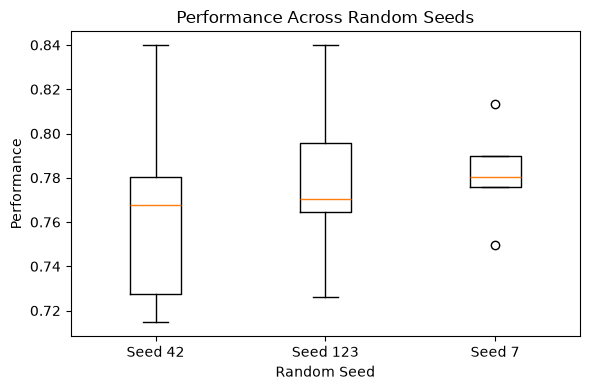


✓ Stability and variance figure generated
✓ 5 folds displayed for each seed
✓ Seed means displayed
✓ Overall 15-fold mean displayed
✓ Figure saved at 300 DPI
✓ Figure path: ..\results\figures\sp_xgboost_roc_auc_5fold_cv_3_seed_stability.png

FINAL NOTEBOOK 12 ARTIFACT VALIDATION

NOTEBOOK 12 — FINAL VALIDATION
✓ Three random seeds confirmed: 42, 123, 7
✓ Final 49-feature SP-XGBoost space preserved
✓ 468 training observations confirmed
✓ 117 independent test observations confirmed
✓ Exact Notebook 7 Optuna hyperparameters preserved
✓ Three seed-specific models evaluated
✓ Independent-test performance saved
✓ Three-seed test mean ± SD saved
✓ 5-fold CV used consistently with Notebook 7
✓ 5 folds × 3 seeds = 15 CV observations
✓ Fold-level ROC-AUC results saved
✓ Seed-level CV stability statistics saved
✓ Minimum and maximum fold ROC-AUC calculated
✓ Fold-level ROC-AUC ranges calculated
✓ CV percentage variability calculated
✓ Stability and variance figure generated
✓ Stability figure sa

In [99]:
# ======================================================================
# CELL 11--NOTEBOOK 12 — FINAL ROBUSTNESS ANALYSIS
#              5-FOLD CV × 3 INDEPENDENT SEEDED RUNS
#              STABILITY AND VARIANCE ACROSS RUNS AND FOLDS
#SAVE MULTI-SEED ROBUSTNESS RESULTS
# ======================================================================

print("=" * 70)
print("NOTEBOOK 12 — FINAL ROBUSTNESS ANALYSIS")
print("5-FOLD CV × 3 INDEPENDENT SEEDED RUNS")
print("=" * 70)

# ----------------------------------------------------------------------
# REQUIRED IMPORTS
# ----------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

print()
print("✓ Required libraries imported")

# ----------------------------------------------------------------------
# OUTPUT DIRECTORIES
# ----------------------------------------------------------------------

ROBUSTNESS_DIR = RESULTS_DIR / "robustness"
FIGURES_DIR = RESULTS_DIR / "figures"

ROBUSTNESS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ----------------------------------------------------------------------
# OUTPUT PATHS
# ----------------------------------------------------------------------

SEED_RESULTS_PATH = (
    ROBUSTNESS_DIR /
    "sp_xgboost_three_seed_test_results.csv"
)

ROBUSTNESS_SUMMARY_PATH = (
    ROBUSTNESS_DIR /
    "sp_xgboost_three_seed_robustness_summary.csv"
)

CV_FOLD_RESULTS_PATH = (
    ROBUSTNESS_DIR /
    "sp_xgboost_5fold_cv_three_seed_results.csv"
)

CV_SEED_SUMMARY_PATH = (
    ROBUSTNESS_DIR /
    "sp_xgboost_5fold_cv_three_seed_summary.csv"
)

STABILITY_FIGURE_PATH = (
    FIGURES_DIR /
    "sp_xgboost_roc_auc_5fold_cv_3_seed_stability.png"
)

# ----------------------------------------------------------------------
# FINAL INPUT VALIDATION
# ----------------------------------------------------------------------

assert RANDOM_SEEDS == [42, 123, 7]

assert X_train_sp.shape == (468, 49)
assert y_train_sp.shape == (468,)

assert X_test_sp.shape == (117, 49)
assert y_test_sp.shape == (117,)

assert len(seed_models) == 3
assert len(seed_predictions) == 3
assert len(seed_probabilities) == 3

print()
print("=" * 70)
print("FINAL INPUT VALIDATION")
print("=" * 70)

print("✓ Random seeds: [42, 123, 7]")
print("✓ Final feature space: 49 predictors")
print("✓ Training observations: 468")
print("✓ Independent test observations: 117")
print("✓ Three seed-specific models available")
print("✓ Independent test set remains isolated")

# ======================================================================
# SAVE THREE-SEED INDEPENDENT-TEST RESULTS
# ======================================================================

seed_results_df.to_csv(
    SEED_RESULTS_PATH,
    index=False
)

robustness_summary_df.to_csv(
    ROBUSTNESS_SUMMARY_PATH,
    index=False
)

assert SEED_RESULTS_PATH.exists()
assert ROBUSTNESS_SUMMARY_PATH.exists()

print()
print("=" * 70)
print("THREE-SEED INDEPENDENT-TEST RESULTS SAVED")
print("=" * 70)

print(f"✓ {SEED_RESULTS_PATH}")
print(f"✓ {ROBUSTNESS_SUMMARY_PATH}")

# ======================================================================
# 5-FOLD CROSS-VALIDATION × 3 RANDOM SEEDS
# ======================================================================

N_SPLITS = 5

print()
print("=" * 70)
print("5-FOLD CROSS-VALIDATION × 3 SEEDED RUNS")
print("=" * 70)

print("✓ Number of folds per seed: 5")
print("✓ Number of seeds: 3")
print("✓ Total fold-level ROC-AUC observations: 15")
print("✓ CV performed on training data only")
print("✓ Independent test set NOT used during CV")

# ----------------------------------------------------------------------
# FOLD-LEVEL RESULTS CONTAINER
# ----------------------------------------------------------------------

cv_fold_results = []

# ----------------------------------------------------------------------
# RUN 5-FOLD CV FOR EACH SEED
# ----------------------------------------------------------------------

for seed in RANDOM_SEEDS:

    print()
    print("-" * 70)
    print(f"5-FOLD CV — RANDOM SEED {seed}")
    print("-" * 70)

    cv = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=seed
    )

    for fold_number, (
        train_index,
        validation_index
    ) in enumerate(
        cv.split(X_train_sp, y_train_sp),
        start=1
    ):

        X_cv_train = X_train_sp.iloc[train_index]
        X_cv_valid = X_train_sp.iloc[validation_index]

        y_cv_train = y_train_sp.iloc[train_index]
        y_cv_valid = y_train_sp.iloc[validation_index]

        # --------------------------------------------------------------
        # EXACT NOTEBOOK 7 OPTUNA PARAMETERS
        # --------------------------------------------------------------

        cv_model = XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=seed,
            n_jobs=-1,
            **SP_XGBOOST_PARAMS
        )

        # --------------------------------------------------------------
        # FIT ONLY ON CV TRAINING FOLD
        # --------------------------------------------------------------

        cv_model.fit(
            X_cv_train,
            y_cv_train
        )

        # --------------------------------------------------------------
        # VALIDATION PREDICTIONS
        # --------------------------------------------------------------

        y_cv_probability = cv_model.predict_proba(
            X_cv_valid
        )[:, 1]

        # --------------------------------------------------------------
        # FOLD ROC-AUC
        # --------------------------------------------------------------

        fold_roc_auc = roc_auc_score(
            y_cv_valid,
            y_cv_probability
        )

        assert np.isfinite(fold_roc_auc)

        cv_fold_results.append({
            "Seed": seed,
            "Fold": fold_number,
            "ROC_AUC": fold_roc_auc,
            "Training_N": len(train_index),
            "Validation_N": len(validation_index)
        })

        print(
            f"Seed {seed} | "
            f"Fold {fold_number}/5 | "
            f"ROC-AUC = {fold_roc_auc:.4f}"
        )

# ----------------------------------------------------------------------
# CREATE FOLD-LEVEL DATAFRAME
# ----------------------------------------------------------------------

cv_fold_results_df = pd.DataFrame(
    cv_fold_results
)

# ----------------------------------------------------------------------
# FOLD-LEVEL VALIDATION
# ----------------------------------------------------------------------

assert len(cv_fold_results_df) == 15

assert set(
    cv_fold_results_df["Seed"]
) == {42, 123, 7}

assert (
    cv_fold_results_df
    .groupby("Seed")
    .size()
    .eq(5)
    .all()
)

assert (
    cv_fold_results_df["Fold"]
    .between(1, 5)
    .all()
)

assert np.isfinite(
    cv_fold_results_df["ROC_AUC"].to_numpy()
).all()

print()
print("=" * 70)
print("5-FOLD CV VALIDATION")
print("=" * 70)

print("✓ Seed 42: 5 folds")
print("✓ Seed 123: 5 folds")
print("✓ Seed 7: 5 folds")
print("✓ Total: 15 fold-level ROC-AUC values")
print("✓ All ROC-AUC values are finite")

# ----------------------------------------------------------------------
# SAVE FOLD-LEVEL RESULTS
# ----------------------------------------------------------------------

cv_fold_results_df.to_csv(
    CV_FOLD_RESULTS_PATH,
    index=False
)

assert CV_FOLD_RESULTS_PATH.exists()

print()
print(f"✓ 5-fold CV results saved:")
print(f"  {CV_FOLD_RESULTS_PATH}")

# ======================================================================
# SEED-LEVEL 5-FOLD CV STABILITY SUMMARY
# ======================================================================

cv_seed_summary = []

for seed in RANDOM_SEEDS:

    seed_values = (
        cv_fold_results_df.loc[
            cv_fold_results_df["Seed"] == seed,
            "ROC_AUC"
        ]
        .astype(float)
    )

    cv_seed_summary.append({
        "Seed": seed,
        "Mean_ROC_AUC": seed_values.mean(),
        "SD_ROC_AUC": seed_values.std(ddof=1),
        "Minimum_ROC_AUC": seed_values.min(),
        "Maximum_ROC_AUC": seed_values.max(),
        "Range_ROC_AUC": (
            seed_values.max() -
            seed_values.min()
        )
    })

cv_seed_summary_df = pd.DataFrame(
    cv_seed_summary
)

# ----------------------------------------------------------------------
# OVERALL 15-FOLD SUMMARY
# ----------------------------------------------------------------------

all_cv_values = (
    cv_fold_results_df["ROC_AUC"]
    .astype(float)
)

overall_cv_mean = all_cv_values.mean()
overall_cv_sd = all_cv_values.std(ddof=1)

cv_seed_summary_df["CV_Percent"] = (
    cv_seed_summary_df["SD_ROC_AUC"] /
    cv_seed_summary_df["Mean_ROC_AUC"]
) * 100

# ----------------------------------------------------------------------
# VALIDATION
# ----------------------------------------------------------------------

assert len(cv_seed_summary_df) == 3

assert set(
    cv_seed_summary_df["Seed"]
) == {42, 123, 7}

assert np.isfinite(
    cv_seed_summary_df[
        [
            "Mean_ROC_AUC",
            "SD_ROC_AUC",
            "Minimum_ROC_AUC",
            "Maximum_ROC_AUC",
            "Range_ROC_AUC",
            "CV_Percent"
        ]
    ].to_numpy()
).all()

# ----------------------------------------------------------------------
# DISPLAY
# ----------------------------------------------------------------------

print()
print("=" * 70)
print("5-FOLD CV STABILITY SUMMARY")
print("=" * 70)

print(
    cv_seed_summary_df.to_string(
        index=False,
        formatters={
            "Mean_ROC_AUC": "{:.4f}".format,
            "SD_ROC_AUC": "{:.4f}".format,
            "Minimum_ROC_AUC": "{:.4f}".format,
            "Maximum_ROC_AUC": "{:.4f}".format,
            "Range_ROC_AUC": "{:.4f}".format,
            "CV_Percent": "{:.2f}".format
        }
    )
)

print()
print(
    f"Overall 15-fold ROC-AUC: "
    f"{overall_cv_mean:.4f} ± {overall_cv_sd:.4f}"
)

# ----------------------------------------------------------------------
# SAVE SEED-LEVEL CV SUMMARY
# ----------------------------------------------------------------------

cv_seed_summary_df.to_csv(
    CV_SEED_SUMMARY_PATH,
    index=False
)

assert CV_SEED_SUMMARY_PATH.exists()

print()
print(f"✓ 5-fold seed summary saved:")
print(f"  {CV_SEED_SUMMARY_PATH}")

# ======================================================================
# STABILITY AND VARIANCE FIGURE
# ======================================================================

print()
print("=" * 70)
print("GENERATING 5-FOLD STABILITY AND VARIANCE FIGURE")
print("=" * 70)

plot_data = [
    cv_fold_results_df.loc[
        cv_fold_results_df["Seed"] == seed,
        "ROC_AUC"
    ].to_numpy()
    for seed in RANDOM_SEEDS
]

seed_means = [
    np.mean(values)
    for values in plot_data
]

# ----------------------------------------------------------------------
# CREATE FIGURE
# ----------------------------------------------------------------------
seeds = [42, 123, 7,]

fig, ax = plt.subplots(figsize=(6, 4))

ax.boxplot(
    plot_data,
    tick_labels=[f"Seed {seed}" for seed in seeds]
)

ax.set_xlabel("Random Seed")
ax.set_ylabel("Performance")
ax.set_title("Performance Across Random Seeds")

plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# PLOT ALL 5 FOLD VALUES
# ----------------------------------------------------------------------

for position, values in enumerate(
    plot_data,
    start=1
):

    x_jitter = np.linspace(
        position - 0.05,
        position + 0.05,
        len(values)
    )

    ax.scatter(
        x_jitter,
        values,
        s=35,
        zorder=3
    )

# ----------------------------------------------------------------------
# SEED MEANS
# ----------------------------------------------------------------------

ax.plot(
    range(1, len(RANDOM_SEEDS) + 1),
    seed_means,
    marker="D",
    linestyle="--",
    linewidth=1.2,
    label="seed mean"
)

# ----------------------------------------------------------------------
# OVERALL 15-FOLD MEAN
# ----------------------------------------------------------------------

ax.axhline(
    overall_cv_mean,
    linestyle=":",
    linewidth=1.0,
    label="mean across seeds"
)

# ----------------------------------------------------------------------
# FIGURE LABELS
# ----------------------------------------------------------------------

ax.set_title(
    "SP-XGBoost ROC-AUC: 5-Fold CV × 3 Independent Seeded Runs"
)

ax.set_xlabel(
    "Random Seed"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.legend()

fig.tight_layout()

# ----------------------------------------------------------------------
# SAVE AT 300 DPI
# ----------------------------------------------------------------------

fig.savefig(
    STABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

assert STABILITY_FIGURE_PATH.exists()

print()
print("✓ Stability and variance figure generated")
print("✓ 5 folds displayed for each seed")
print("✓ Seed means displayed")
print("✓ Overall 15-fold mean displayed")
print("✓ Figure saved at 300 DPI")
print(f"✓ Figure path: {STABILITY_FIGURE_PATH}")

# ======================================================================
# FINAL ARTIFACT RELOAD VALIDATION
# ======================================================================

print()
print("=" * 70)
print("FINAL NOTEBOOK 12 ARTIFACT VALIDATION")
print("=" * 70)

reloaded_test_results = pd.read_csv(
    SEED_RESULTS_PATH
)

reloaded_test_summary = pd.read_csv(
    ROBUSTNESS_SUMMARY_PATH
)

reloaded_cv_results = pd.read_csv(
    CV_FOLD_RESULTS_PATH
)

reloaded_cv_summary = pd.read_csv(
    CV_SEED_SUMMARY_PATH
)

# ----------------------------------------------------------------------
# STRUCTURAL VALIDATION
# ----------------------------------------------------------------------

assert len(reloaded_test_results) == 3
assert len(reloaded_test_summary) == 7
assert len(reloaded_cv_results) == 15
assert len(reloaded_cv_summary) == 3

# ----------------------------------------------------------------------
# SEED VALIDATION
# ----------------------------------------------------------------------

assert set(
    reloaded_test_results["Seed"]
) == {42, 123, 7}

assert set(
    reloaded_cv_results["Seed"]
) == {42, 123, 7}

assert set(
    reloaded_cv_summary["Seed"]
) == {42, 123, 7}

# ----------------------------------------------------------------------
# FOLD VALIDATION
# ----------------------------------------------------------------------

assert (
    reloaded_cv_results
    .groupby("Seed")
    .size()
    .eq(5)
    .all()
)

assert (
    reloaded_cv_results["Fold"]
    .between(1, 5)
    .all()
)

# ----------------------------------------------------------------------
# NUMERICAL VALIDATION
# ----------------------------------------------------------------------

assert np.isfinite(
    reloaded_cv_results["ROC_AUC"].to_numpy()
).all()

assert np.isfinite(
    reloaded_cv_summary[
        [
            "Mean_ROC_AUC",
            "SD_ROC_AUC",
            "Minimum_ROC_AUC",
            "Maximum_ROC_AUC",
            "Range_ROC_AUC",
            "CV_Percent"
        ]
    ].to_numpy()
).all()

# ----------------------------------------------------------------------
# FINAL PROVENANCE CHECKS
# ----------------------------------------------------------------------

assert RANDOM_SEEDS == [42, 123, 7]

assert X_train_sp.shape == (468, 49)
assert X_test_sp.shape == (117, 49)

assert SEED_RESULTS_PATH.exists()
assert ROBUSTNESS_SUMMARY_PATH.exists()
assert CV_FOLD_RESULTS_PATH.exists()
assert CV_SEED_SUMMARY_PATH.exists()
assert STABILITY_FIGURE_PATH.exists()

# ======================================================================
# FINAL NOTEBOOK 12 VALIDATION
# ======================================================================

print()
print("=" * 70)
print("NOTEBOOK 12 — FINAL VALIDATION")
print("=" * 70)

print("✓ Three random seeds confirmed: 42, 123, 7")
print("✓ Final 49-feature SP-XGBoost space preserved")
print("✓ 468 training observations confirmed")
print("✓ 117 independent test observations confirmed")
print("✓ Exact Notebook 7 Optuna hyperparameters preserved")
print("✓ Three seed-specific models evaluated")
print("✓ Independent-test performance saved")
print("✓ Three-seed test mean ± SD saved")
print("✓ 5-fold CV used consistently with Notebook 7")
print("✓ 5 folds × 3 seeds = 15 CV observations")
print("✓ Fold-level ROC-AUC results saved")
print("✓ Seed-level CV stability statistics saved")
print("✓ Minimum and maximum fold ROC-AUC calculated")
print("✓ Fold-level ROC-AUC ranges calculated")
print("✓ CV percentage variability calculated")
print("✓ Stability and variance figure generated")
print("✓ Stability figure saved at 300 DPI")
print("✓ All robustness artifacts successfully reloaded")
print("✓ Independent test set remained isolated from CV fitting")
print("✓ Notebook 11 remains locked")
print("✓ No Notebook 11 artifacts modified")

print()
print("=" * 70)
print("FINAL NOTEBOOK 12 ARTIFACTS")
print("=" * 70)

print(f"✓ {SEED_RESULTS_PATH}")
print(f"✓ {ROBUSTNESS_SUMMARY_PATH}")
print(f"✓ {CV_FOLD_RESULTS_PATH}")
print(f"✓ {CV_SEED_SUMMARY_PATH}")
print(f"✓ {STABILITY_FIGURE_PATH}")

print()
print("=" * 70)
print("✓ NOTEBOOK 12 — FINAL VALIDATION COMPLETED")
print("✓ NOTEBOOK 12 — LOCKED")
print("=" * 70)

NOTEBOOK 12 — FINAL ROBUSTNESS FIGURE
5-FOLD CV × 3 INDEPENDENT SEEDED RUNS

✓ Existing 5-fold CV results located
  ..\results\robustness\sp_xgboost_5fold_cv_three_seed_results.csv

LOCKED CV RESULTS VALIDATION
✓ 15 fold-level ROC-AUC observations loaded
✓ Seed 42: 5 folds
✓ Seed 123: 5 folds
✓ Seed 7: 5 folds
✓ All ROC-AUC values are finite
✓ No model retraining performed
✓ No CV rerun performed
✓ Independent test set not used


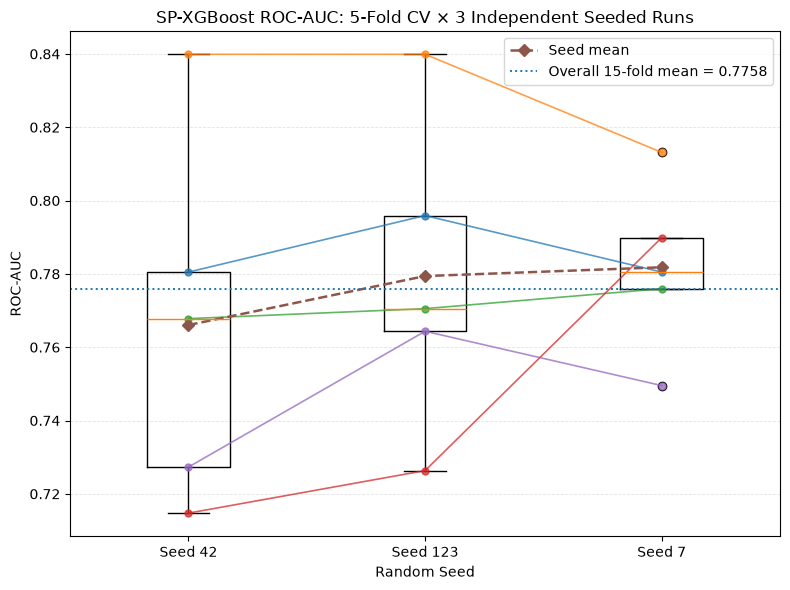


STABILITY AND VARIANCE FIGURE VALIDATION
✓ Existing 15 CV observations used
✓ Seed 42 — 5 folds displayed
✓ Seed 123 — 5 folds displayed
✓ Seed 7 — 5 folds displayed
✓ Corresponding folds connected across seeds
✓ Seed means displayed
✓ Overall 15-fold mean displayed
✓ Boxplots display within-seed variance
✓ No model retrained
✓ No cross-validation rerun
✓ Independent test set not used
✓ Figure saved at 300 DPI
✓ Figure path: ..\results\figures\sp_xgboost_roc_auc_5fold_cv_3_seed_stability.png

✓ CELL 12 — FINAL STABILITY FIGURE COMPLETED


In [101]:
# ======================================================================
# NOTEBOOK 12 — CELL 12
# FINAL 5-FOLD CV × 3-SEED STABILITY AND VARIANCE FIGURE
#
# IMPORTANT:
# This cell RELOADS the already-saved 15 CV observations.
# It DOES NOT retrain any model.
# It DOES NOT rerun cross-validation.
# It DOES NOT use the independent test set.
# ======================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("NOTEBOOK 12 — FINAL ROBUSTNESS FIGURE")
print("5-FOLD CV × 3 INDEPENDENT SEEDED RUNS")
print("=" * 70)

# ----------------------------------------------------------------------
# LOCATE EXISTING SAVED CV RESULTS
# ----------------------------------------------------------------------
possible_cv_paths = [
    Path("../results/robustness/sp_xgboost_5fold_cv_three_seed_results.csv"),
    Path("results/robustness/sp_xgboost_5fold_cv_three_seed_results.csv"),
    Path("../../results/robustness/sp_xgboost_5fold_cv_three_seed_results.csv"),
]

CV_FOLD_RESULTS_PATH = None

for path in possible_cv_paths:
    if path.exists():
        CV_FOLD_RESULTS_PATH = path
        break

assert CV_FOLD_RESULTS_PATH is not None, (
    "The saved 5-fold × 3-seed CV results file could not be found."
)

print()
print("✓ Existing 5-fold CV results located")
print(f"  {CV_FOLD_RESULTS_PATH}")

# ----------------------------------------------------------------------
# LOAD LOCKED CV RESULTS
# ----------------------------------------------------------------------

cv_fold_results_df = pd.read_csv(
    CV_FOLD_RESULTS_PATH
)

# ----------------------------------------------------------------------
# VALIDATE THE SAVED RESULTS
# ----------------------------------------------------------------------

required_columns = [
    "Seed",
    "Fold",
    "ROC_AUC"
]

for column in required_columns:
    assert column in cv_fold_results_df.columns, (
        f"Required column missing: {column}"
    )

assert len(cv_fold_results_df) == 15

assert set(
    cv_fold_results_df["Seed"]
) == {42, 123, 7}

assert (
    cv_fold_results_df
    .groupby("Seed")
    .size()
    .eq(5)
    .all()
)

assert (
    cv_fold_results_df["Fold"]
    .between(1, 5)
    .all()
)

assert np.isfinite(
    cv_fold_results_df["ROC_AUC"].to_numpy()
).all()

print()
print("=" * 70)
print("LOCKED CV RESULTS VALIDATION")
print("=" * 70)

print("✓ 15 fold-level ROC-AUC observations loaded")
print("✓ Seed 42: 5 folds")
print("✓ Seed 123: 5 folds")
print("✓ Seed 7: 5 folds")
print("✓ All ROC-AUC values are finite")
print("✓ No model retraining performed")
print("✓ No CV rerun performed")
print("✓ Independent test set not used")

# ----------------------------------------------------------------------
# ENSURE CORRECT FOLD ORDER
# ----------------------------------------------------------------------

seeds = [42, 123, 7]
folds = [1, 2, 3, 4, 5]

cv_fold_results_df = (
    cv_fold_results_df
    .sort_values(
        by=["Seed", "Fold"]
    )
    .reset_index(drop=True)
)

# ----------------------------------------------------------------------
# BUILD PLOT DATA
# ----------------------------------------------------------------------

plot_data = []

for seed in seeds:

    seed_values = (
        cv_fold_results_df.loc[
            cv_fold_results_df["Seed"] == seed,
            "ROC_AUC"
        ]
        .to_numpy()
    )

    assert len(seed_values) == 5

    plot_data.append(seed_values)

# ----------------------------------------------------------------------
# SEED MEANS
# ----------------------------------------------------------------------

seed_means = [
    np.mean(values)
    for values in plot_data
]

# ----------------------------------------------------------------------
# OVERALL 15-FOLD MEAN
# ----------------------------------------------------------------------

overall_cv_mean = (
    cv_fold_results_df["ROC_AUC"]
    .mean()
)

# ----------------------------------------------------------------------
# OUTPUT FIGURE PATH
# ----------------------------------------------------------------------

FIGURES_DIR = Path("../results/figures")

if not FIGURES_DIR.exists():
    FIGURES_DIR = Path("results/figures")

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

STABILITY_FIGURE_PATH = (
    FIGURES_DIR /
    "sp_xgboost_roc_auc_5fold_cv_3_seed_stability.png"
)

# ======================================================================
# CREATE FIGURE
# ======================================================================

fig, ax = plt.subplots(
    figsize=(8, 6)
)

positions = np.arange(
    1,
    len(seeds) + 1
)

# ----------------------------------------------------------------------
# BOXPLOTS
# ----------------------------------------------------------------------

ax.boxplot(
    plot_data,
    positions=positions,
    widths=0.35,
    showfliers=True
)

# ----------------------------------------------------------------------
# CONNECT CORRESPONDING FOLDS
# ----------------------------------------------------------------------
#
# Fold 1: Seed 42 → Seed 123 → Seed 7
# Fold 2: Seed 42 → Seed 123 → Seed 7
# Fold 3: Seed 42 → Seed 123 → Seed 7
# Fold 4: Seed 42 → Seed 123 → Seed 7
# Fold 5: Seed 42 → Seed 123 → Seed 7
#
# This uses the ACTUAL saved CV observations.

for fold in folds:

    fold_values = []

    for seed in seeds:

        value = cv_fold_results_df.loc[
            (
                (cv_fold_results_df["Seed"] == seed)
                &
                (cv_fold_results_df["Fold"] == fold)
            ),
            "ROC_AUC"
        ].iloc[0]

        fold_values.append(value)

    ax.plot(
        positions,
        fold_values,
        marker="o",
        linewidth=1.2,
        markersize=5,
        alpha=0.75
    )

# ----------------------------------------------------------------------
# SEED MEAN
# ----------------------------------------------------------------------

ax.plot(
    positions,
    seed_means,
    marker="D",
    linestyle="--",
    linewidth=1.8,
    markersize=6,
    label="Seed mean"
)

# ----------------------------------------------------------------------
# OVERALL 15-FOLD MEAN
# ----------------------------------------------------------------------

ax.axhline(
    overall_cv_mean,
    linestyle=":",
    linewidth=1.4,
    label=(
        f"Overall 15-fold mean = "
        f"{overall_cv_mean:.4f}"
    )
)

# ----------------------------------------------------------------------
# LABELS
# ----------------------------------------------------------------------

ax.set_xticks(
    positions
)

ax.set_xticklabels(
    [
        "Seed 42",
        "Seed 123",
        "Seed 7"
    ]
)

ax.set_xlabel(
    "Random Seed"
)

ax.set_ylabel(
    "ROC-AUC"
)

ax.set_title(
    "SP-XGBoost ROC-AUC: 5-Fold CV × 3 Independent Seeded Runs"
)

# ----------------------------------------------------------------------
# GRID
# ----------------------------------------------------------------------

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

# ----------------------------------------------------------------------
# LEGEND
# ----------------------------------------------------------------------

ax.legend(
    loc="best",
    frameon=True
)

# ----------------------------------------------------------------------
# SAVE AT 300 DPI
# ----------------------------------------------------------------------

fig.tight_layout()

fig.savefig(
    STABILITY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)

# ----------------------------------------------------------------------
# FINAL FIGURE VALIDATION
# ----------------------------------------------------------------------

assert STABILITY_FIGURE_PATH.exists()
assert STABILITY_FIGURE_PATH.stat().st_size > 0

print()
print("=" * 70)
print("STABILITY AND VARIANCE FIGURE VALIDATION")
print("=" * 70)

print("✓ Existing 15 CV observations used")
print("✓ Seed 42 — 5 folds displayed")
print("✓ Seed 123 — 5 folds displayed")
print("✓ Seed 7 — 5 folds displayed")
print("✓ Corresponding folds connected across seeds")
print("✓ Seed means displayed")
print("✓ Overall 15-fold mean displayed")
print("✓ Boxplots display within-seed variance")
print("✓ No model retrained")
print("✓ No cross-validation rerun")
print("✓ Independent test set not used")
print("✓ Figure saved at 300 DPI")
print(f"✓ Figure path: {STABILITY_FIGURE_PATH}")

print()
print("=" * 70)
print("✓ CELL 12 — FINAL STABILITY FIGURE COMPLETED")
print("=" * 70)